# 03 · Benchmark de Machine Learning con validación temporal

Este notebook compara varios modelos tabulares para predecir `PIR_target` utilizando exactamente la misma población, variables, ventanas temporales y métricas.

En un problema temporal no es válido mezclar aleatoriamente partidos pasados y futuros. Por ello, el protocolo *walk-forward* entrena con fechas anteriores y evalúa en la siguiente ventana cronológica, imitando el uso real del modelo.

La comparación incluye una referencia simple, tres modelos lineales regularizados, tres métodos basados en árboles y dos implementaciones de boosting moderno. LightGBM y XGBoost se evalúan con configuración fija y con tuning temporal interno.

Para mantener la comparabilidad, todos los modelos reciben las mismas 36 variables, los mismos folds externos y las mismas métricas. El test futuro de cada fold se utiliza una sola vez y nunca participa en la selección de hiperparámetros.

In [1]:
from pathlib import Path
import platform
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "reports").is_dir():
            return candidate
    raise FileNotFoundError("No se encontró el raíz del proyecto (data/raw y reports).")

ROOT = find_project_root()
RAW_DIR = ROOT / "data" / "raw"
PROCESSED_DIR = ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 100)
plt.style.use("seaborn-v0_8-whitegrid")
print({"root": str(ROOT), "python": sys.version.split()[0], "pandas": pd.__version__, "platform": platform.platform()})

import json
import time

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

SEED = 42
np.random.seed(SEED)
TABLE_DIR = ROOT / "reports" / "tables" / "03_ml_benchmark"
FIGURE_DIR = ROOT / "reports" / "figures" / "03_ml_benchmark"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

dataset_path = PROCESSED_DIR / "player_pregame_target_game_3_5_1718.csv"
if not dataset_path.exists():
    raise FileNotFoundError("Ejecuta primero 01_eda_y_limpieza.ipynb y 02_construccion_datasets.ipynb")
dataset = pd.read_csv(dataset_path, parse_dates=["Date", "target_date", "previous_appearance_date"])
assert len(dataset) == 7_269 and dataset["player_id"].nunique() == 712
print({"rows": len(dataset), "players": dataset.player_id.nunique(), "target": "PIR_target"})

{'root': 'C:\\Users\\pablo\\OneDrive\\Documentos\\TFM\\tfm-scouting-ml-dl', 'python': '3.12.4', 'pandas': '2.2.2', 'platform': 'Windows-10-10.0.19045-SP0'}
{'rows': 7269, 'players': 712, 'target': 'PIR_target'}


## Registro de variables predictoras

Se utilizan las medias históricas de 5 y 10 apariciones, la competición y los días de descanso. Se excluyen los recuentos auxiliares, identificadores, fechas, estadísticas del partido objetivo y la propia variable objetivo.

El registro se construye explícitamente y se comprueba antes de entrenar. Esta celda es el contrato de entrada compartido por todos los modelos tabulares.

In [2]:
rolling_features = sorted(
    column for column in dataset.columns
    if "_roll" in column and not column.endswith("_count")
)
FEATURES = ["competition", *rolling_features, "rest_days_player"]
TARGET = "PIR_target"
TARGET_DATE = "target_date"
FORBIDDEN = {"PIR", "PIR_target", "Date", "target_date", "days_to_next_game", "MP_min"}

assert len(FEATURES) == 36, f"Número de features inesperado: {len(FEATURES)}"
assert not FORBIDDEN.intersection(FEATURES)
assert sum(column.endswith("_count") for column in FEATURES) == 0

feature_manifest = pd.DataFrame({
    "feature": FEATURES,
    "type": ["categorical" if column == "competition" else "numeric" for column in FEATURES],
    "available_before_target": True,
})
feature_manifest.to_csv(TABLE_DIR / "feature_manifest.csv", index=False)
display(feature_manifest)

,feature,type,available_before_target
0,competition,categorical,True
1,3P_rate_roll10,numeric,True
2,3P_rate_roll5,numeric,True
3,AST_TOV_roll10,numeric,True
4,AST_TOV_roll5,numeric,True
5,AST_roll10,numeric,True
6,AST_roll5,numeric,True
7,DRB_roll10,numeric,True
8,DRB_roll5,numeric,True
9,FGA_roll10,numeric,True


## Calendario walk-forward

Se fijan cinco ventanas consecutivas del calendario y se reutilizarán sin cambios en todos los modelos ML y DL. En cada fold el entrenamiento crece, pero el test siempre permanece estrictamente en el futuro. Persistir el calendario impide que un notebook posterior altere inadvertidamente la comparación.

In [3]:
def fold_indices(frame, schedule_row):
    dates = pd.to_datetime(frame[TARGET_DATE])
    train = np.flatnonzero(dates <= schedule_row["train_end"])
    test = np.flatnonzero((dates >= schedule_row["test_start"]) & (dates <= schedule_row["test_end"]))
    assert len(train) and len(test)
    assert dates.iloc[train].max() < dates.iloc[test].min()
    return train, test

schedule = pd.DataFrame([
    {"fold": 1, "train_end": "2017-12-15", "test_start": "2017-12-16", "test_end": "2017-12-22"},
    {"fold": 2, "train_end": "2017-12-22", "test_start": "2017-12-23", "test_end": "2017-12-30"},
    {"fold": 3, "train_end": "2017-12-30", "test_start": "2017-12-31", "test_end": "2018-01-06"},
    {"fold": 4, "train_end": "2018-01-06", "test_start": "2018-01-07", "test_end": "2018-01-13"},
    {"fold": 5, "train_end": "2018-01-13", "test_start": "2018-01-14", "test_end": "2018-01-21"},
])
for column in ["train_end", "test_start", "test_end"]:
    schedule[column] = pd.to_datetime(schedule[column])
schedule.to_csv(TABLE_DIR / "fold_schedule.csv", index=False, date_format="%Y-%m-%d")
display(schedule)

,fold,train_end,test_start,test_end
0,1,2017-12-15,2017-12-16,2017-12-22
1,2,2017-12-22,2017-12-23,2017-12-30
2,3,2017-12-30,2017-12-31,2018-01-06
3,4,2018-01-06,2018-01-07,2018-01-13
4,5,2018-01-13,2018-01-14,2018-01-21


## Preprocesado y modelos

La competición se convierte en tres indicadores binarios mediante *one-hot encoding*. Los valores numéricos ausentes se completan con la mediana calculada únicamente en el entrenamiento de cada fold. Los modelos lineales llevan además las variables a una escala comparable, mientras que los modelos basados en árboles conservan sus valores originales.

Todos estos pasos se agrupan en un `Pipeline` de scikit-learn, es decir, en una secuencia que aplica siempre las mismas transformaciones antes de entrenar. De esta forma, ninguna información del periodo de test interviene en el ajuste.

In [4]:
NUMERIC_FEATURES = [column for column in FEATURES if column != "competition"]

def pipeline(regressor, scaled):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scaled:
        numeric_steps.append(("scaler", StandardScaler()))
    preprocess = ColumnTransformer([
        ("competition", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["competition"]),
        ("numeric", Pipeline(numeric_steps), NUMERIC_FEATURES),
    ])
    return Pipeline([("preprocess", preprocess), ("regressor", regressor)])

MODELS = {
    "Baseline_mean": None,
    "Ridge": pipeline(Ridge(alpha=1.0), scaled=True),
    "Lasso": pipeline(Lasso(alpha=0.002, max_iter=30_000, random_state=SEED), scaled=True),
    "ElasticNet": pipeline(ElasticNet(alpha=0.002, l1_ratio=0.2, max_iter=30_000, random_state=SEED), scaled=True),
    "RandomForest": pipeline(RandomForestRegressor(n_estimators=700, min_samples_leaf=5, max_features=0.6, n_jobs=-1, random_state=SEED), scaled=False),
    "ExtraTrees": pipeline(ExtraTreesRegressor(n_estimators=700, min_samples_leaf=3, max_features=0.7, n_jobs=-1, random_state=SEED), scaled=False),
    "HistGradientBoosting": pipeline(HistGradientBoostingRegressor(learning_rate=0.05, max_depth=3, max_iter=800, early_stopping=True, random_state=SEED), scaled=False),
    "LightGBM": pipeline(LGBMRegressor(n_estimators=2_000, learning_rate=0.05, num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, verbosity=-1, n_jobs=1, random_state=SEED), scaled=False),
    "XGBoost": pipeline(XGBRegressor(n_estimators=2_000, learning_rate=0.05, max_depth=4, min_child_weight=5, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, reg_alpha=0.0, objective="reg:squarederror", n_jobs=1, random_state=SEED), scaled=False),
}
model_manifest = pd.DataFrame([
    {"model": "Baseline_mean", "family": "reference", "parameters": "mean(PIR_target_train)", "tuning": "none"},
    {"model": "Ridge", "family": "linear", "parameters": "alpha=1.0", "tuning": "fixed"},
    {"model": "Lasso", "family": "linear", "parameters": "alpha=0.002; max_iter=30000", "tuning": "fixed"},
    {"model": "ElasticNet", "family": "linear", "parameters": "alpha=0.002; l1_ratio=0.2; max_iter=30000", "tuning": "fixed"},
    {"model": "RandomForest", "family": "bagging_trees", "parameters": "n_estimators=700; min_samples_leaf=5; max_features=0.6", "tuning": "fixed"},
    {"model": "ExtraTrees", "family": "bagging_trees", "parameters": "n_estimators=700; min_samples_leaf=3; max_features=0.7", "tuning": "fixed"},
    {"model": "HistGradientBoosting", "family": "boosting", "parameters": "learning_rate=0.05; max_depth=3; max_iter=800; early_stopping=True", "tuning": "fixed"},
    {"model": "LightGBM", "family": "boosting", "parameters": "n_estimators=2000; learning_rate=0.05; num_leaves=31; min_child_samples=50", "tuning": "fixed and randomized"},
    {"model": "XGBoost", "family": "boosting", "parameters": "n_estimators=2000; learning_rate=0.05; max_depth=4; min_child_weight=5", "tuning": "fixed and randomized"},
    {"model": "LightGBM_tuned", "family": "boosting", "parameters": "20 candidates; 3 inner temporal splits", "tuning": "nested randomized search by outer fold"},
    {"model": "XGBoost_tuned", "family": "boosting", "parameters": "20 candidates; 3 inner temporal splits", "tuning": "nested randomized search by outer fold"},
])

TUNING_SPECS = {
    "LightGBM_tuned": {
        "template": MODELS["LightGBM"],
        "parameters": {
            "regressor__num_leaves": [15, 31, 63],
            "regressor__min_child_samples": [20, 50, 100, 150],
            "regressor__subsample": [0.6, 0.8, 0.9],
            "regressor__colsample_bytree": [0.6, 0.8, 0.9],
            "regressor__reg_lambda": [0.0, 1.0, 3.0, 10.0],
            "regressor__learning_rate": [0.03, 0.05, 0.08],
        },
    },
    "XGBoost_tuned": {
        "template": MODELS["XGBoost"],
        "parameters": {
            "regressor__max_depth": [3, 4, 5, 6],
            "regressor__min_child_weight": [1, 3, 5, 10],
            "regressor__subsample": [0.6, 0.8, 0.9],
            "regressor__colsample_bytree": [0.6, 0.8, 0.9],
            "regressor__reg_lambda": [1.0, 2.0, 5.0, 10.0],
            "regressor__reg_alpha": [0.0, 0.5, 1.0, 2.0],
            "regressor__learning_rate": [0.03, 0.05, 0.08],
        },
    },
}
model_manifest.to_csv(TABLE_DIR / "model_manifest.csv", index=False)
display(model_manifest)

,model,family,parameters,tuning
0,Baseline_mean,reference,mean(PIR_target_train),none
1,Ridge,linear,alpha=1.0,fixed
2,Lasso,linear,alpha=0.002; max_iter=30000,fixed
3,ElasticNet,linear,alpha=0.002; l1_ratio=0.2; max_iter=30000,fixed
4,RandomForest,bagging_trees,n_estimators=700; min_samples_leaf=5; max_feat...,fixed
5,ExtraTrees,bagging_trees,n_estimators=700; min_samples_leaf=3; max_feat...,fixed
6,HistGradientBoosting,boosting,learning_rate=0.05; max_depth=3; max_iter=800;...,fixed
7,LightGBM,boosting,n_estimators=2000; learning_rate=0.05; num_lea...,fixed and randomized
8,XGBoost,boosting,n_estimators=2000; learning_rate=0.05; max_dep...,fixed and randomized
9,LightGBM_tuned,boosting,20 candidates; 3 inner temporal splits,nested randomized search by outer fold


## Entrenamiento y evaluación

Para cada fold se guardan el tamaño del entrenamiento y del test, las predicciones individuales y las métricas globales y por competición. La métrica principal es MAE porque expresa el error medio en puntos PIR; RMSE penaliza especialmente errores grandes y R² contextualiza la variabilidad explicada.

In [5]:
ordered = dataset.sort_values([TARGET_DATE, "competition", "player_id", "match_id"]).reset_index(drop=True)
X, y = ordered[FEATURES], pd.to_numeric(ordered[TARGET], errors="raise")
metric_rows, prediction_frames, size_rows, tuning_rows, cost_rows = [], [], [], [], []

def record_evaluation(fold, model_name, y_true, prediction, meta):
    base = {"fold": fold, "model": model_name}
    rows = [{
        **base, "competition": "ALL", "n_test": len(y_true),
        "mae": mean_absolute_error(y_true, prediction),
        "rmse": np.sqrt(mean_squared_error(y_true, prediction)),
        "r2": r2_score(y_true, prediction),
    }]
    for competition in sorted(meta["competition"].unique()):
        mask = meta["competition"].eq(competition).to_numpy()
        rows.append({
            **base, "competition": competition, "n_test": int(mask.sum()),
            "mae": mean_absolute_error(y_true.to_numpy()[mask], prediction[mask]),
            "rmse": np.sqrt(mean_squared_error(y_true.to_numpy()[mask], prediction[mask])),
            "r2": r2_score(y_true.to_numpy()[mask], prediction[mask]),
        })
    pred = meta.copy()
    pred["fold"], pred["model"] = fold, model_name
    pred["y_true"], pred["y_pred"] = y_true.to_numpy(), prediction
    pred["residual"] = pred["y_true"] - pred["y_pred"]
    return rows, pred

for _, schedule_row in schedule.iterrows():
    fold = int(schedule_row["fold"])
    train_idx, test_idx = fold_indices(ordered, schedule_row)
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    meta = ordered.iloc[test_idx][["competition", "player_id", "match_id", TARGET_DATE]].copy()
    size_rows.append({
        "fold": fold, "train_rows": len(train_idx), "test_rows": len(test_idx),
        "train_end": schedule_row["train_end"], "test_start": schedule_row["test_start"], "test_end": schedule_row["test_end"],
    })
    for model_name, template in MODELS.items():
        started = time.perf_counter()
        if template is None:
            prediction = np.full(len(y_test), y_train.mean())
        else:
            estimator = clone(template)
            estimator.fit(X_train, y_train)
            prediction = estimator.predict(X_test)
        elapsed = time.perf_counter() - started
        rows, pred = record_evaluation(fold, model_name, y_test, np.asarray(prediction), meta)
        metric_rows.extend(rows)
        prediction_frames.append(pred)
        cost_rows.append({"fold": fold, "model": model_name, "fit_and_predict_seconds": elapsed, "tuned": False})

    inner_cv = TimeSeriesSplit(n_splits=3)
    for model_name, specification in TUNING_SPECS.items():
        started = time.perf_counter()
        search = RandomizedSearchCV(
            estimator=clone(specification["template"]),
            param_distributions=specification["parameters"],
            n_iter=20,
            scoring="neg_mean_absolute_error",
            cv=inner_cv,
            random_state=SEED,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )
        search.fit(X_train, y_train)
        prediction = search.best_estimator_.predict(X_test)
        elapsed = time.perf_counter() - started
        rows, pred = record_evaluation(fold, model_name, y_test, np.asarray(prediction), meta)
        metric_rows.extend(rows)
        prediction_frames.append(pred)
        tuning_rows.append({
            "fold": fold,
            "model": model_name,
            "inner_cv_splits": 3,
            "n_iter": 20,
            "best_inner_mae": -float(search.best_score_),
            "best_parameters": json.dumps(search.best_params_, sort_keys=True),
        })
        cost_rows.append({"fold": fold, "model": model_name, "fit_and_predict_seconds": elapsed, "tuned": True})
        print(f"fold={fold} model={model_name} inner_MAE={-search.best_score_:.4f} seconds={elapsed:.1f}")

metrics = pd.DataFrame(metric_rows)
predictions = pd.concat(prediction_frames, ignore_index=True)
fold_sizes = pd.DataFrame(size_rows)
tuning_results = pd.DataFrame(tuning_rows)
training_cost = pd.DataFrame(cost_rows)
summary_global = (metrics.query("competition == 'ALL'").groupby("model")[["mae", "rmse", "r2"]]
                  .agg(["mean", "std"]))
summary_global.columns = ["_".join(column) for column in summary_global.columns]
summary_global = summary_global.reset_index().sort_values("mae_mean")
summary_competition = (metrics.query("competition != 'ALL'").groupby(["model", "competition"])[["mae", "rmse", "r2"]]
                       .agg(["mean", "std"]))
summary_competition.columns = ["_".join(column) for column in summary_competition.columns]
summary_competition = summary_competition.reset_index()

expected_elasticnet_mae = np.array([5.7952595337, 5.8979958660, 5.6791160901, 5.7982205528, 5.3552534606])
observed_elasticnet_mae = metrics.query("competition == 'ALL' and model == 'ElasticNet'").sort_values("fold")["mae"].to_numpy()
assert np.allclose(observed_elasticnet_mae, expected_elasticnet_mae, atol=1e-9)
assert np.isclose(summary_global.set_index("model").loc["ElasticNet", "mae_mean"], 5.7051691006, atol=1e-9)

metrics.to_csv(TABLE_DIR / "metrics_by_fold_competition.csv", index=False)
predictions.to_csv(TABLE_DIR / "predictions.csv", index=False, date_format="%Y-%m-%d")
fold_sizes.to_csv(TABLE_DIR / "fold_sizes.csv", index=False, date_format="%Y-%m-%d")
summary_global.to_csv(TABLE_DIR / "summary_global.csv", index=False)
summary_competition.to_csv(TABLE_DIR / "summary_by_competition.csv", index=False)
tuning_results.to_csv(TABLE_DIR / "tuning_results.csv", index=False)
training_cost.to_csv(TABLE_DIR / "training_cost.csv", index=False)
assert metrics.query("competition == 'ALL'")["model"].nunique() == 11
assert len(tuning_results) == 10
display(summary_global, tuning_results, fold_sizes)

C:\Users\pablo\anaconda3\envs\tfm-scouting-ml-dl\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\pablo\anaconda3\envs\tfm-scouting-ml-dl\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


fold=1 model=LightGBM_tuned inner_MAE=6.0129 seconds=71.0
fold=1 model=XGBoost_tuned inner_MAE=6.0149 seconds=83.7
fold=2 model=LightGBM_tuned inner_MAE=6.0800 seconds=72.0
fold=2 model=XGBoost_tuned inner_MAE=6.0007 seconds=92.8
fold=3 model=LightGBM_tuned inner_MAE=6.0955 seconds=82.6
fold=3 model=XGBoost_tuned inner_MAE=6.0855 seconds=83.5
fold=4 model=LightGBM_tuned inner_MAE=6.0864 seconds=91.3
fold=4 model=XGBoost_tuned inner_MAE=6.0543 seconds=92.4
fold=5 model=LightGBM_tuned inner_MAE=6.0755 seconds=99.8
fold=5 model=XGBoost_tuned inner_MAE=6.0480 seconds=93.2


,model,mae_mean,mae_std,rmse_mean,rmse_std,r2_mean,r2_std
4,Lasso,5.703432,0.208934,7.220431,0.258652,0.196875,0.041236
1,ElasticNet,5.705169,0.210402,7.221093,0.259856,0.196728,0.041411
8,Ridge,5.706634,0.208243,7.221896,0.258106,0.196551,0.041092
7,RandomForest,5.730360,0.221859,7.253831,0.278069,0.189402,0.044874
2,ExtraTrees,5.737379,0.234193,7.276796,0.283260,0.184262,0.045814
3,HistGradientBoosting,5.741674,0.204340,7.249625,0.255765,0.190396,0.040115
10,XGBoost_tuned,5.852057,0.337650,7.460914,0.405975,0.141467,0.081550
9,XGBoost,5.983706,0.283324,7.646429,0.337490,0.098827,0.065734
6,LightGBM_tuned,6.009461,0.294428,7.641605,0.378947,0.099612,0.077414
5,LightGBM,6.045083,0.298908,7.726631,0.379806,0.079506,0.077927


,fold,model,inner_cv_splits,n_iter,best_inner_mae,best_parameters
0,1,LightGBM_tuned,3,20,6.012946,"{""regressor__colsample_bytree"": 0.9, ""regresso..."
1,1,XGBoost_tuned,3,20,6.014866,"{""regressor__colsample_bytree"": 0.8, ""regresso..."
2,2,LightGBM_tuned,3,20,6.080029,"{""regressor__colsample_bytree"": 0.9, ""regresso..."
3,2,XGBoost_tuned,3,20,6.000678,"{""regressor__colsample_bytree"": 0.9, ""regresso..."
4,3,LightGBM_tuned,3,20,6.095550,"{""regressor__colsample_bytree"": 0.8, ""regresso..."
5,3,XGBoost_tuned,3,20,6.085465,"{""regressor__colsample_bytree"": 0.6, ""regresso..."
6,4,LightGBM_tuned,3,20,6.086372,"{""regressor__colsample_bytree"": 0.9, ""regresso..."
7,4,XGBoost_tuned,3,20,6.054273,"{""regressor__colsample_bytree"": 0.6, ""regresso..."
8,5,LightGBM_tuned,3,20,6.075482,"{""regressor__colsample_bytree"": 0.8, ""regresso..."
9,5,XGBoost_tuned,3,20,6.048047,"{""regressor__colsample_bytree"": 0.6, ""regresso..."


,fold,train_rows,test_rows,train_end,test_start,test_end
0,1,4008,739,2017-12-15,2017-12-16,2017-12-22
1,2,4747,647,2017-12-22,2017-12-23,2017-12-30
2,3,5394,522,2017-12-30,2017-12-31,2018-01-06
3,4,5916,517,2018-01-06,2018-01-07,2018-01-13
4,5,6433,836,2018-01-13,2018-01-14,2018-01-21


## Comparación visual y estabilidad temporal

La primera figura compara el MAE medio y su desviación entre folds para las once variantes evaluadas. La segunda muestra la evolución temporal de las cinco mejores por MAE para conservar legibilidad; su CSV fuente contiene las once y permite ampliar la comparación en Power BI.

Una diferencia pequeña frente a la desviación observada no debe presentarse como una superioridad general del modelo.

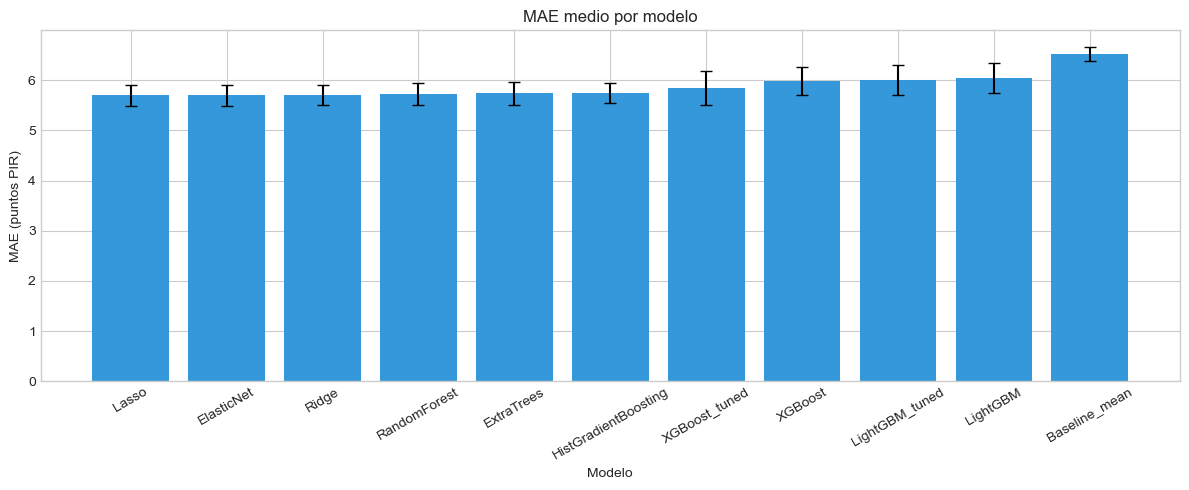

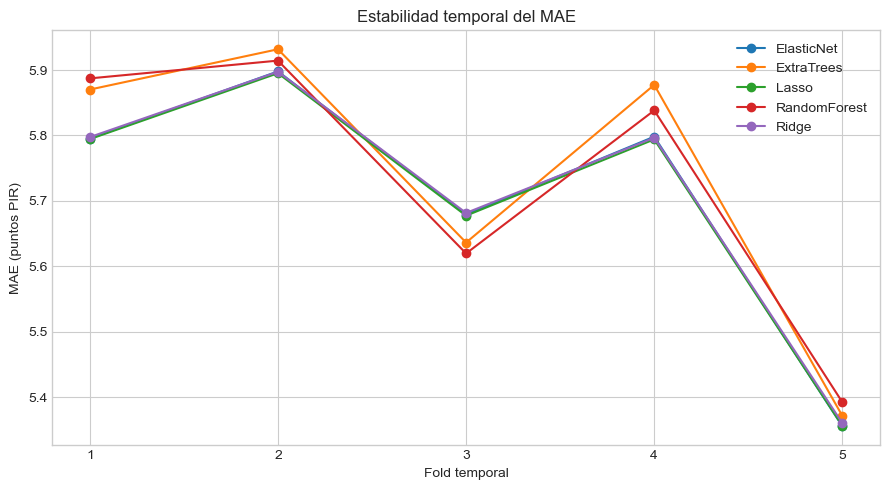

In [6]:
model_order = summary_global["model"].tolist()
plot_summary = summary_global[["model", "mae_mean", "mae_std", "rmse_mean", "r2_mean"]].copy()
plot_folds = metrics.query("competition == 'ALL'")[["fold", "model", "n_test", "mae", "rmse", "r2"]].copy()
plot_summary.to_csv(TABLE_DIR / "figure_model_comparison_source.csv", index=False)
plot_folds.to_csv(TABLE_DIR / "figure_fold_stability_source.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_summary["model"], plot_summary["mae_mean"], yerr=plot_summary["mae_std"], capsize=4, color="#3498db")
ax.set(title="MAE medio por modelo", xlabel="Modelo", ylabel="MAE (puntos PIR)")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_mae_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

top_five = model_order[:5]
fig, ax = plt.subplots(figsize=(9, 5))
for model, frame in plot_folds[plot_folds["model"].isin(top_five)].groupby("model"):
    ax.plot(frame["fold"], frame["mae"], marker="o", label=model)
ax.set(title="Estabilidad temporal del MAE", xlabel="Fold temporal", ylabel="MAE (puntos PIR)", xticks=range(1, 6))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_mae_by_fold.png", dpi=160, bbox_inches="tight")
plt.show()

## Conclusión

Los resultados se interpretan conjuntamente mediante MAE, RMSE, R², variabilidad entre folds y coste. El tuning no garantiza una mejora en el test futuro: solo selecciona la configuración con menor MAE dentro del entrenamiento de cada fold.

Una diferencia pequeña frente a la variabilidad temporal no demuestra superioridad general. Estos resultados describen esta temporada, población, variables y protocolo; tampoco permiten atribuir causalidad a ninguna característica.